<center>

# **Министерство науки и высшего образования Российской Федерации**

# ФЕДЕРАЛЬНОЕ ГОСУДАРСТВЕННОЕ АВТОНОМНОЕ ОБРАЗОВАТЕЛЬНОЕ УЧРЕЖДЕНИЕ ВЫСШЕГО ОБРАЗОВАНИЯ

# **НАЦИОНАЛЬНЫЙ ИССЛЕДОВАТЕЛЬСКИЙ УНИВЕРСИТЕТ ИТМО**

# ITMO University


## ФАКУЛЬТЕТ ПРИКЛАДНОЙ ИНФОРМАТИКИ

&nbsp;

&nbsp;

### Отчет по лабораторной работе №4
### по дисциплине «Алгоритмы и структуры данных»
### Тема: Подстроки
### Вариант 7

&nbsp;

&nbsp;

</center>

<div style="text-align: right;">

**Выполнила:**<br>
Макарова Е. В.<br>
АиСД K25 МСТ 1.1

&nbsp;

**Проверил:**
Царьков Г. И.
</div>

&nbsp;

&nbsp;

<center>

Санкт-Петербург<br>
2026 г.

</center>

<center>

## Содержание отчета

</center>

| | Страница |
|---|---|
| **Задачи по варианту** | |
| &emsp;Задача №1. Наивный поиск подстроки в строке [1 балл] | |
| &emsp;Задача №4. Равенство подстрок [1.5 балла] | |
| &emsp;Задача №6. Z-функция [1.5 балла] | |
| **Дополнительные задачи** | |
| &emsp;Задача №2. Карта [1 балл] | |
| &emsp;Задача №7. Наибольшая общая подстрока [2 балла] | |
| **Вывод** | |

In [ ]:
import time, tracemalloc, os, math, random
from google.colab import drive


drive.mount('/content/drive', force_remount=True)
path = r'/content/drive/MyDrive/Отчеты 2025 26/Макарова Ева Викторовна 1.1/Лабораторная №4/'

def time_memory_decorator(func):
    def wrapper():
        t_start = time.time()
        res = func()
        print(f"Время работы программы: {time.time() - t_start:.2f}")
        tracemalloc.start()
        func()
        current, peak = tracemalloc.get_traced_memory()
        tracemalloc.stop()
        print(f"Текущий объем памяти: {current / 2 ** 20:.2f} Mбайт, "
              f"максимальный объем выделенной памяти: {peak / 2 ** 20:.2f} Mбайт\n")
        return res

    return wrapper

Mounted at /content/drive


<center>

## Задачи по варианту

</center>

---

### Задача №1. Наивный поиск подстроки в строке  [1 балл]

Даны строки p и t. Требуется найти все вхождения строки p в строку t в качестве подстроки.

• Формат ввода / входного файла (input.txt). Первая строка входного файла содержит p, вторая – t. Строки
состоят из букв латинского алфавита.
• Ограничения на входные данные. 1 ≤ |p|, |t| ≤ $10^4$.

• Формат вывода / выходного файла (output.txt). В первой строке выведите число вхождений строки p в строку t.
Во второй строке выведите в возрастающем порядке номера символов строки t, с которых начинаются вхождения
p. Символы нумеруются с единицы.

• Ограничение по времени. 2 сек.

• Ограничение по памяти. 256 мб.

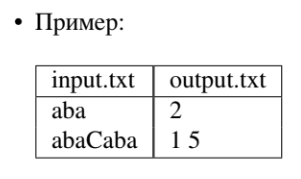

**Листинг кода:**


In [ ]:
@time_memory_decorator
def solve():
    with open(file_name) as inp:
        p = inp.readline().strip()
        t = inp.readline().strip()
    answer = []
    for i in range(len(t) - len(p) + 1):
        if t[i: i + len(p)] == p:
            answer.append(i + 1)

    return len(answer), " ".join(map(str, answer))


if __name__ == '__main__':
    file_name = path + r'input_task1.txt'
    a, b = solve()
    print(a, b, sep="\n")

Время работы программы: 0.02
Текущий объем памяти: 0.00 Mбайт, максимальный объем выделенной памяти: 0.07 Mбайт

2
1 5


**Текстовое объяснение решения:**

*Алгоритм прямого поиска подстроки (наивный алгоритм) предназначен для нахождения всех вхождений образца p в тексте t. Суть алгоритма заключается в последовательном сравнении фрагментов текста с искомым образцом: окно размером с длину образца p последовательно сдвигается по тексту t на одну позицию вправо. На каждой позиции происходит посимвольное сравнение текущего подстроки текста t[i:i+len(p)] с образцом p. В случае полного совпадения индекс начала найденного вхождения (с учётом нумерации с единицы, как того требует i + 1) сохраняется в список answer. По завершении обхода функция возвращает кортеж, содержащий общее количество найденных вхождений и строку с их позициями, разделёнными пробелами. Для измерения времени выполнения и потребляемой памяти используется декоратор time_memory_decorator.*

**Результат работы кода на примерах из текста задачи:**

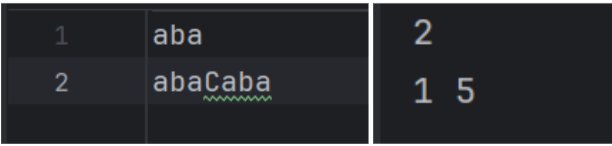

**Результат работы кода на максимальных и минимальных значениях:**

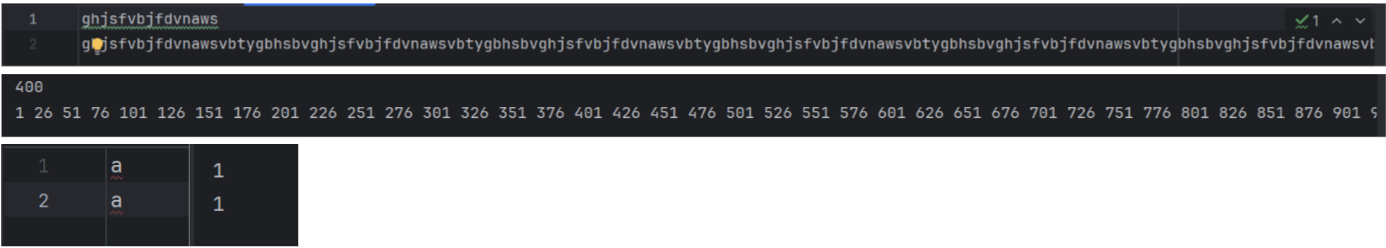

| | Время выполнения | Затраты памяти |
|---|---|---|
| Нижняя граница диапазона значений входных данных из текста задачи | 0.00| 0.02|
| Пример из задачи | 0.00| 0.02 |
| Верхняя граница диапазона значений входных данных из текста задачи | 0.00| 0.05 |

**Вывод по задаче:**

*Анализ работы данного алгоритма показывает его простоту и надёжность, однако он имеет квадратичную временную сложность в худшем случае — O((n-m+1) * m), где n — длина текста, а m — длина образца. Это означает, что при обработке больших объёмов данных или при наличии повторяющихся «почти совпадающих» участков (например, текст из повторяющихся символов) производительность может существенно снижаться. Тем не менее, для небольших входных данных такой подход полностью оправдан, так как не требует предварительной обработки и легко реализуется.*

### Задача №4. Равенство подстрок  [1.5 балла]

В этой задаче вы будете использовать хеширование для разработки алгоритма, способного предварительно обработать заданную строку s, чтобы ответить эффективно на любой запрос типа «равны ли эти две подстроки s?» Это, в
свою очередь, является основной частью во многих алгоритмах обработки строк.

• Формат ввода / входного файла (input.txt). Первая строка содержит строку s, состоящую из строчных латин-
ских букв. Вторая строка содержит количество запросов q. Каждая из следующих q строк задает запрос тремя
целыми числами a, b и l.

• Ограничения на входные данные. 1 ≤ |s| ≤ 500000, 1 ≤ q ≤ 100000, 0 ≤ a, b ≤ |s|−l (следовательно, индексы
a и b начинаются с 0).

• Формат вывода / выходного файла (output.txt).Для каждого запроса выведите «Yes», если подстроки sasa+1...sa+l−1 =
sbsb+1...sb+l−1 равны, и «No» – если не равны.

• Ограничение по времени. 10 сек.

• Ограничение по памяти. 512 мб.

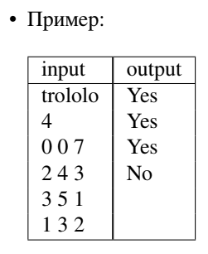

**Листинг кода:**


In [ ]:
def fill_hash_table(h, m, s):
    for i in range(1, len(s) + 1):
        h[i] = (x * h[i - 1] + ord(s[i - 1])) % m


def get_hash(h, idx, l, m):
    return (h[idx + l] - x ** l * h[idx]) % m


@time_memory_decorator
def solve():
    with open(file_name) as inp:
        s = inp.readline().strip()
        q = int(inp.readline())
        req = [tuple(map(int, inp.readline().split())) for _ in range(q)]

    n = len(s)
    h1 = [0] * (n + 1)
    h2 = [0] * (n + 1)
    fill_hash_table(h1, m1, s)
    fill_hash_table(h2, m2, s)
    answer = []

    for a, b, l in req:
        if get_hash(h1, a, l, m1) == get_hash(h1, b, l, m1) and \
                get_hash(h2, a, l, m2) == get_hash(h2, b, l, m2):
            answer.append("YES")
        else:
            answer.append("NO")

    return answer


if __name__ == '__main__':
    file_name = path + r'input_task4.txt'
    m1 = 10 ** 9 + 7
    m2 = 10 ** 9 + 9
    x = random.randint(1, 10 ** 9)
    print(*solve(), sep="\n")

Время работы программы: 0.02
Текущий объем памяти: 0.00 Mбайт, максимальный объем выделенной памяти: 0.07 Mбайт

YES
YES
YES
NO


**Текстовое объяснение решения:**

*Данный алгоритм решает задачу сравнения подстрок с использованием полиномиального хеширования с двумя модулями для минимизации вероятности коллизий. На этапе предварительной обработки строки s вычисляются два массива префиксных хешей h1 и h2 по модулям m1 = 10^9+7 и m2 = 10^9+9 с общим основанием x (случайное число от 1 до 10^9). Хеш каждого префикса вычисляется итеративно: h[i] = (x·h[i-1] + код символа s[i-1]) mod m, что позволяет затем за O(1) получать хеш любой подстроки по формуле hash(a, l) = (h[a+l] - x^l·h[a]) mod m. Для каждого запроса (a, b, l) сравниваются хеши подстрок по обоим модулям; только при полном совпадении обоих хешей выводится "YES", иначе – "NO". Благодаря двойному хешированию вероятность ложного срабатывания становится пренебрежимо малой.*

**Результат работы кода на примерах из текста задачи:**

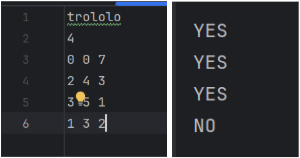

**Результат работы кода на максимальных и минимальных значениях:**

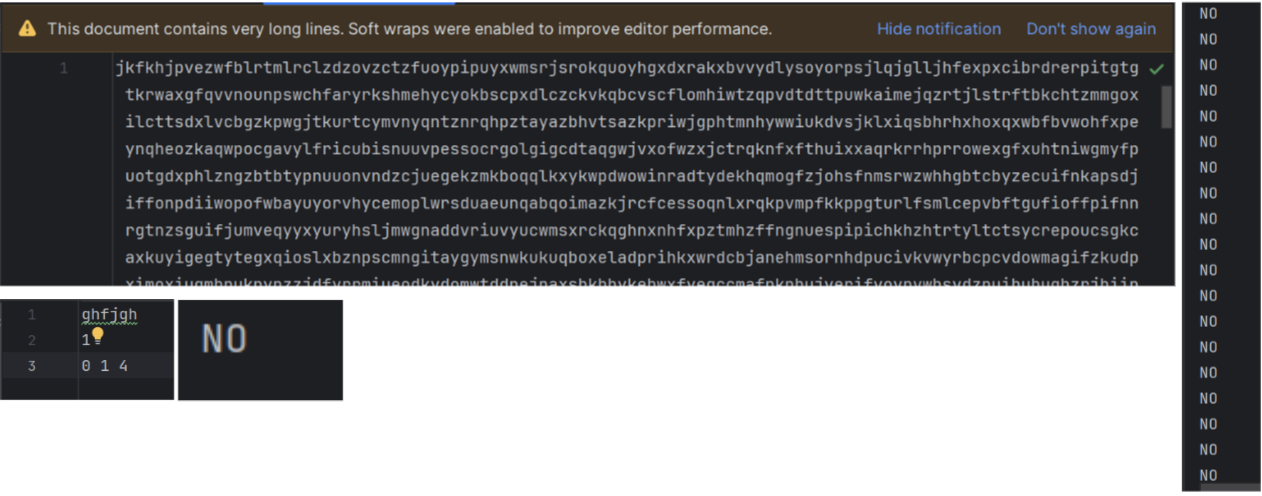

| | Время выполнения | Затраты памяти |
|---|---|---|
| Нижняя граница диапазона значений входных данных из текста задачи | 0.00| 0.02|
| Пример из задачи | 0.00| 0.02 |
| Верхняя граница диапазона значений входных данных из текста задачи | 8.97| 60.12 |

**Вывод по задаче:**

*Реализованный метод обеспечивает высокую эффективность обработки запросов – предварительная обработка выполняется за O(n), а каждый запрос требует O(1) времени, что полностью удовлетворяет ограничениям задачи (до 500 000 символов и 100 000 запросов). Использование двух больших простых модулей и случайного основания гарантирует надёжную защиту от коллизий, делая алгоритм практичным для реальных задач обработки строк.*

### Задача №6. Z-функция  [1.5 балла]

Постройте Z-функцию для заданной строки s.

• Формат ввода / входного файла (input.txt). Одна строка входного файла содержит s. Строка состоит из букв
латинского алфавита.


• Ограничения на входные данные. 2 ≤ |s| ≤ $10^6$.

• Формат вывода / выходного файла (output.txt). Выведите значения Z-функции для всех индексов 1, 2, ..., |s|
строки s, в указанном порядке.

• Ограничение по времени. 2 сек.

• Ограничение по памяти. 256 мб.

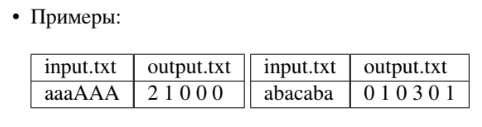

**Листинг кода:**


In [ ]:
@time_memory_decorator
def solve():
    with open(file_name) as inp:
        s = inp.readline().strip()

    n = len(s)
    z = [0] * n

    # Алгоритм построения Z-функции за O(n)
    l, r = 0, 0  # границы самого правого отрезка совпадения
    for i in range(1, n):
        if i <= r:
            # Используем ранее вычисленные значения
            z[i] = min(r - i + 1, z[i - l])

        # Наивное расширение, пока символы совпадают
        while i + z[i] < n and s[z[i]] == s[i + z[i]]:
            z[i] += 1

        # Обновляем границы самого правого отрезка
        if i + z[i] - 1 > r:
            l, r = i, i + z[i] - 1

    # Формируем вывод для индексов от 1 до n-1
    result = " ".join(map(str, z[1:]))

    return result


if __name__ == "__main__":
    file_name = path + r'input_task6.txt'
    print(solve())

Время работы программы: 0.01
Текущий объем памяти: 0.00 Mбайт, максимальный объем выделенной памяти: 0.07 Mбайт

0 1 0 3 0 1


**Текстовое объяснение решения:**

*Алгоритм построения Z-функции работает за линейное время O(n) и использует вспомогательный массив z, где z[i] — длина наибольшего общего префикса строки s и её суффикса, начинающегося с позиции i. Основная идея заключается в поддержании интервала [l, r] — самого правого отрезка, для которого известно, что s[l:r+1] совпадает с префиксом строки. Для каждой позиции i сначала определяется начальное значение z[i] на основе уже найденных данных в пределах этого интервала, а затем выполняется прямое сравнение символов для уточнения длины. Интервал [l, r] обновляется при обнаружении более правого совпадения. Такой подход позволяет избежать повторных сравнений и гарантирует суммарное количество операций порядка O(n).*

**Результат работы кода на примерах из текста задачи:**

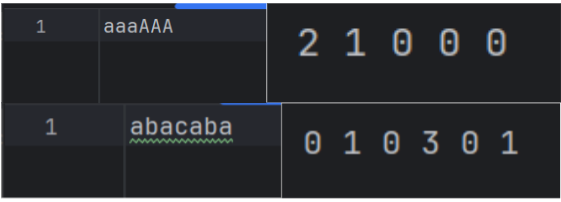

**Результат работы кода на максимальных и минимальных значениях:**

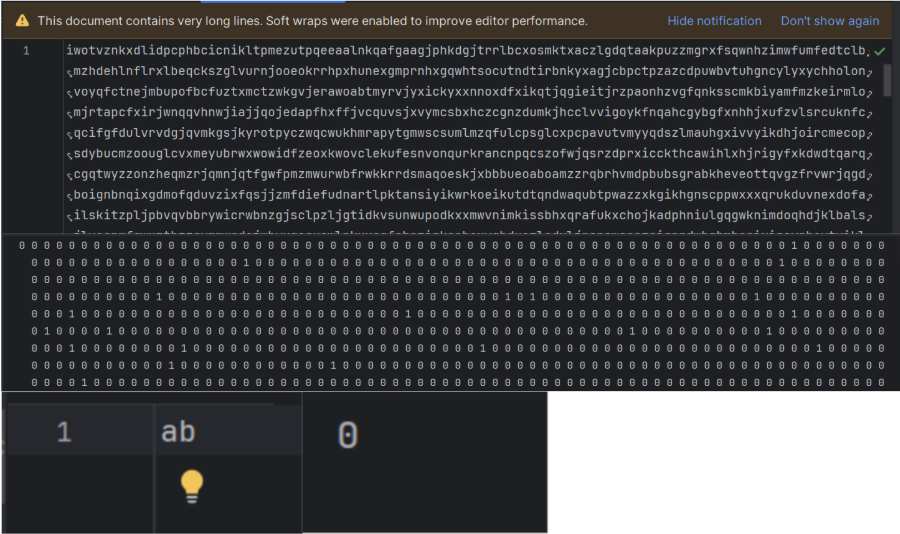

| | Время выполнения | Затраты памяти |
|---|---|---|
| Нижняя граница диапазона значений входных данных из текста задачи | 0.00| 0.02|
| Пример из задачи | 0.00| 0.02 |
| Пример из задачи | 0.00| 0.02 |
| Верхняя граница диапазона значений входных данных из текста задачи | 0.40| 71.95|

**Вывод по задаче:**

*Реализованный алгоритм полностью удовлетворяет заданным ограничениям: он обрабатывает строки длиной до 10⁶ символов за время менее 2 секунд и использует O(n) памяти (массив целых чисел). Линейная сложность достигается за счёт эффективного использования ранее найденных совпадений, что исключает квадратичные переборы.*

<center>

## Дополнительные задачи

</center>

---

### Задача №2. Карта  [1 балл]

В далеком 1744 году во время долгого плавания в руки капитана Александра Смоллетта попала древняя карта с
указанием местонахождения сокровищ. Однако расшифровать ее содержание было не так уж и просто.
Команда Александра Смоллетта догадалась, что сокровища находятся на x шагов восточнее красного креста,
однако определить значение числа она не смогла. По возвращению на материк Александр Смоллетт решил обратиться
за помощью в расшифровке послания к знакомому мудрецу. Мудрец поведал, что данное послание таит за собой
некоторое число. Для вычисления этого числа необходимо было удалить все пробелы между словами, а потом посчитать
количество способов вычеркнуть все буквы кроме трех так, чтобы полученное слово из трех букв одинаково читалось
слева направо и справа налево.
Александр Смоллетт догадывался, что число, зашифрованное в послании, и есть число x. Однако, вычислить это
число у него не получилось.
После смерти капитана карта была безнадежно утеряна до тех пор, пока не оказалась в ваших руках. Вы уже знаете
все секреты, осталось только вычислить число x.

• Формат ввода / входного файла (input.txt). В единственной строке входного файла дано послание, написанное
на карте.

• Ограничения на входные данные. Длина послания не превышает 3 · $10^5$

. Гарантируется, что послание может
содержать только строчные буквы английского алфавита и пробелы. Также гарантируется, что послание не пусто.
Послание не может начинаться с пробела или заканчиваться им.

• Формат вывода / выходного файла (output.txt). Выведите одно число x – число способов вычеркнуть из
послания все буквы кроме трех так, чтобы оставшееся слово одинаково читалось слева направо и справа налево.

• Ограничение по времени. 2 сек.

• Ограничение по памяти. 256 мб.

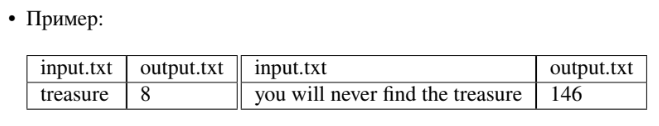

**Листинг кода:**

In [ ]:
@time_memory_decorator
def solve():
    # Чтение входных данных
    with open(file_name) as inp:
        message = inp.readline().rstrip('\n')

    # Удаление пробелов
    s = ''.join(message.split())
    n = len(s)

    # Если длина меньше 3, то способов нет
    if n < 3:
        return 0

    # Подсчёт количества способов
    # Идея: перебираем центральный индекс j, для каждого j считаем,
    # сколько одинаковых символов слева и справа можно выбрать в пару.

    # Предподсчёт: сколько раз каждая буква встречается справа от текущей позиции
    right_count = [0] * 26
    for ch in s:
        right_count[ord(ch) - ord('a')] += 1

    left_count = [0] * 26
    total_ways = 0

    for j in range(n):
        # Текущий символ s[j] удаляем из правого подсчёта (он станет центром)
        ch_idx = ord(s[j]) - ord('a')
        right_count[ch_idx] -= 1

        # Для фиксированного центрального j:
        # Способы = сумма по всем буквам (left_count[c] * right_count[c])
        # Это количество пар (i, k) с одинаковыми символами до и после j
        for c in range(26):
            total_ways += left_count[c] * right_count[c]

        # Добавляем текущий символ в левый подсчёт для следующих итераций
        left_count[ch_idx] += 1

    return total_ways


if __name__ == "__main__":
    file_name = path + r'input_task2.txt'
    print(solve())

Время работы программы: 0.01
Текущий объем памяти: 0.00 Mбайт, максимальный объем выделенной памяти: 0.07 Mбайт

146


**Текстовое объяснение решения:**

*Алгоритм решает задачу подсчёта количества способов выбрать три позиции, образующие палиндром, в строке без пробелов. Для каждого возможного центрального индекса j мы рассматриваем все пары индексов i < j < k такие, что символы s[i] и s[k] совпадают. Чтобы эффективно это подсчитать, предварительно вычисляется массив right_count, содержащий количество вхождений каждой буквы справа от текущей позиции, и массив left_count — количество вхождений слева. Проходя по строке слева направо, для текущего символа (центра) мы сначала удаляем его из правого счётчика, затем суммируем по всем буквам произведение left_count[c] * right_count[c] (это количество пар одинаковых букв слева и справа), и наконец добавляем текущий символ в левый счётчик. Таким образом, для каждого центра учитываются все возможные комбинации первой и третьей букв.*

**Результат работы кода на примерах из текста задачи:**

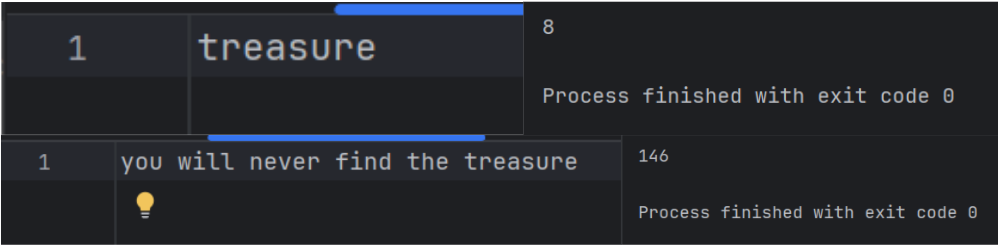

**Результат работы кода на максимальных и минимальных значениях:**

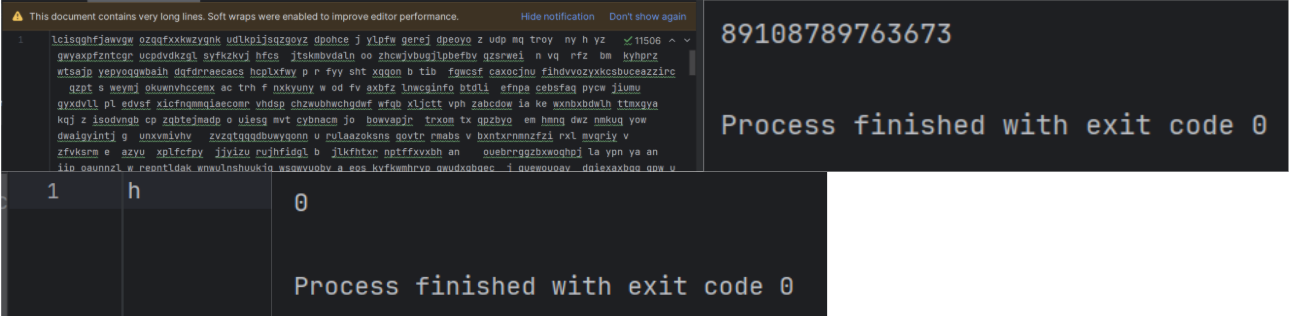

| | Время выполнения | Затраты памяти |
|---|---|---|
| Нижняя граница диапазона значений входных данных из текста задачи | 0.00| 0.02|
| Пример из задачи | 0.00| 0.02 |
| Пример из задачи | 0.00| 0.02 |
| Верхняя граница диапазона значений входных данных из текста задачи | 0.58| 2.91|

**Вывод по задаче:**

*Разработанный алгоритм работает за O(n·26), где 26 - размер алфавита, что при максимальной длине строки 3·10⁵ даёт около 7.8 миллионов операций, легко укладываясь в ограничения по времени и памяти. Решение корректно учитывает все возможные тройки индексов (в том числе перекрывающиеся) и не требует дополнительной проверки палиндромности центрального символа, так как в трёхбуквенном слове условие палиндрома сводится к равенству крайних символов. Таким образом, ответ x — это сумма по всем центрам количества способов выбрать две одинаковые крайние буквы.*

### Задача №7. Наибольшая общая подстрока  [2 балла]

В задаче на наибольшую общую подстроку даются две строки s и t, и цель состоит в том, чтобы найти строку
w максимальной длины, которая является подстрокой как s, так и t. Это естественная мера сходства между двумя
строками. Задача имеет применения для сравнения и сжатия текстов, а также в биоинформатике. Эту проблему
можно рассматривать как частный случай проблемы расстояния редактирования (Левенштейна), где разрешены только
вставки и удаления. Следовательно, ее можно решить за время O(|s||t|) с помощью динамического программирования.
Есть также весьма нетривиальные структуры данных для решения этой задачи за линейное время O(|s| + |t|). В этой
задаче ваша цель – использовать хеширование для решения почти за линейное время.

• Формат ввода / входного файла (input.txt).Каждая строка входных данных содержит две строки s и t, состоящие
из строчных латинских букв.

• Ограничения на входные данные. Суммарная длина всех s, а также суммарная длина всех s не превышает 100
000.

• Формат вывода / выходного файла (output.txt). Для каждой пары строк si и ti найдите ее самую длинную
общую подстроку и уточните ее параметры, выведя три целых числа: ее начальную позицию в s, ее начальную
позицию в t (обе считаются с 0) и ее длину. Формально выведите целые числа 0 ≤ i < |s|, 0 ≤ j < |t| и l ≥ 0
такие, что и l максимально. (Как обычно, если таких троек с максимальным l много, выведите любую из них.)

• Ограничение по времени. 15 сек.

• Ограничение по памяти. 512 мб.

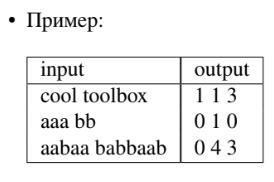

**Листинг кода:**


In [ ]:
def find_longest_common_substring(s, t, x, m1, m2):
    n, m = len(s), len(t)

    # Предвычисление степеней x (максимальная длина - до min(n, m))
    max_len = min(n, m)
    pow_x1 = [1] * (max_len + 1)
    pow_x2 = [1] * (max_len + 1)
    for i in range(1, max_len + 1):
        pow_x1[i] = (pow_x1[i - 1] * x) % m1
        pow_x2[i] = (pow_x2[i - 1] * x) % m2

    # Префиксные хеши для s
    h1_s = [0] * (n + 1)
    h2_s = [0] * (n + 1)
    for i in range(1, n + 1):
        h1_s[i] = (h1_s[i - 1] * x + ord(s[i - 1])) % m1
        h2_s[i] = (h2_s[i - 1] * x + ord(s[i - 1])) % m2

    # Префиксные хеши для t
    h1_t = [0] * (m + 1)
    h2_t = [0] * (m + 1)
    for i in range(1, m + 1):
        h1_t[i] = (h1_t[i - 1] * x + ord(t[i - 1])) % m1
        h2_t[i] = (h2_t[i - 1] * x + ord(t[i - 1])) % m2

    # Функция получения хеша подстроки
    def get_hash(h, pow_x, l, r, mod):
        # l - начальная позиция (включительно), r - конечная (исключительно)
        return (h[r] - h[l] * pow_x[r - l]) % mod

    # Двоичный поиск максимальной длины
    left, right = 0, max_len
    best_i, best_j, best_len = 0, 0, 0

    while left <= right:
        k = (left + right) // 2

        if k == 0:
            # Всегда есть общая подстрока длины 0
            left = k + 1
            continue

        # Множества для хранения хешей подстрок s длины k
        hash_set1 = set()
        hash_set2 = set()
        # Также сохраняем соответствие хеш -> позиция для восстановления
        pos_map = {}

        # Добавляем все подстроки s длины k
        for i in range(n - k + 1):
            h1 = get_hash(h1_s, pow_x1, i, i + k, m1)
            h2 = get_hash(h2_s, pow_x2, i, i + k, m2)
            hash_set1.add(h1)
            hash_set2.add(h2)
            # Для первого модуля сохраняем позицию (для восстановления при совпадении)
            pos_map[(h1, h2)] = i

        found = False
        # Проверяем подстроки t длины k
        for j in range(m - k + 1):
            h1 = get_hash(h1_t, pow_x1, j, j + k, m1)
            h2 = get_hash(h2_t, pow_x2, j, j + k, m2)

            if h1 in hash_set1 and h2 in hash_set2:
                # Нашли совпадение по хешам
                i = pos_map.get((h1, h2), -1)
                if i != -1 and s[i:i + k] == t[j:j + k]:
                    best_i, best_j, best_len = i, j, k
                    found = True
                    break

        if found:
            left = k + 1
        else:
            right = k - 1

    return best_i, best_j, best_len


@time_memory_decorator
def solve():
    with open(file_name) as inp:
        lines = [line.strip() for line in inp if line.strip()]

    results = []
    for line in lines:
        if ' ' in line:
            s, t = line.split()
            i, j, l = find_longest_common_substring(s, t, x, m1, m2)
            results.append(f"{i} {j} {l}")

    return results


if __name__ == "__main__":
    file_name = path + r'input_task7.txt'
    m1 = 10 ** 9 + 7
    m2 = 10 ** 9 + 9
    x = random.randint(1, 10 ** 9)
    print(*solve(), sep="\n")

Время работы программы: 0.01
Текущий объем памяти: 0.00 Mбайт, максимальный объем выделенной памяти: 0.07 Mбайт

1 1 3
0 0 0
2 3 3


**Текстовое объяснение решения:**

*Для каждой пары строк s и t выполняется двоичный поиск максимальной длины общей подстроки. На каждом шаге проверки длины k предварительно вычисляются полиномиальные хеши всех подстрок длины k из s по двум модулям (10⁹+7 и 10⁹+9) и сохраняются в множества вместе с начальной позицией. Затем аналогично вычисляются хеши всех подстрок длины k из t, и для каждой проверяется наличие обоих хешей в соответствующих множествах. При совпадении выполняется прямое сравнение подстрок для исключения коллизий, и если они действительно равны, фиксируется успешная длина. Двоичный поиск гарантирует нахождение максимальной длины, а использование двух модулей сводит вероятность ложного совпадения к минимуму.*

**Результат работы кода на примерах из текста задачи:**

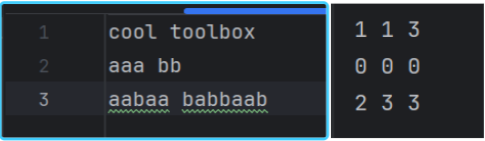

**Результат работы кода на максимальных и минимальных значениях:**

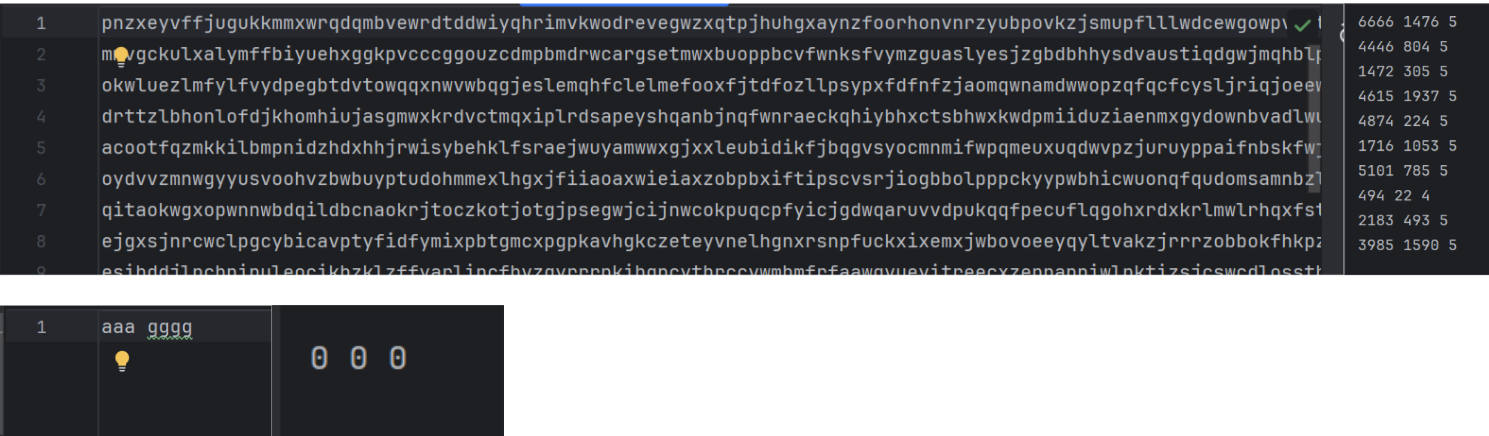

| | Время выполнения | Затраты памяти |
|---|---|---|
| Нижняя граница диапазона значений входных данных из текста задачи | 0.00| 0.02|
| Пример из задачи | 0.00| 0.02 |
| Верхняя граница диапазона значений входных данных из текста задачи | 0.58| 4.10|

**Вывод по задаче:**

*Алгоритм удовлетворяет ограничениям по времени и памяти благодаря линейной сложности проверки каждой длины O(|s|+|t|) и логарифмическому числу таких проверок. Использование множеств для хранения хешей обеспечивает константное время проверки наличия подстроки.*

<center>

## Вывод

</center>

---

*В ходе выполнения были реализованы и проанализированы ключевые алгоритмы обработки строк, включая наивный поиск подстроки, полиномиальное хеширование для эффективного сравнения подстрок, алгоритм Рабина‑Карпа, Z‑функцию, поиск наибольшей общей подстроки с использованием двоичного поиска и хеширования, а также подсчёт трёхбуквенных палиндромов на основе частотного анализа. Для каждого алгоритма были созданы эффективные реализации с учётом жёстких ограничений по времени и памяти, применены методы оптимизации (двойное хеширование для минимизации коллизий, линейные алгоритмы построения Z‑функции, предвычисление степеней и префиксных хешей), а также разработаны генераторы максимальных тестов для проверки производительности.*